# Ejercicio 4 - Analisis exploratorio utilizando DuckDB

## 0. Configuracion

In [1]:
import os
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORES = {"yellow": "#E0A800", "green": "#2E8B57"}
DIAS = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]

con = duckdb.connect()   # base en memoria


def q(sql):
    # Ejecuta la consulta en DuckDB y devuelve el resultado (ya agregado) como DataFrame.
    inicio = time.perf_counter()
    df = con.sql(sql).df()
    print(f"{len(df)} filas | {time.perf_counter() - inicio:.2f} s")
    return df


print("DuckDB", con.sql("SELECT version()").fetchone()[0])

DuckDB v1.5.5


### 0.1 Vistas sobre los archivos Parquet

In [2]:
con.sql(r'''
CREATE OR REPLACE VIEW viajes AS
SELECT
    split_part(filename, '/', 3)                                        AS tipo,
    strptime(regexp_extract(filename, '(\d{4}-\d{2})\.parquet$', 1), '%Y-%m')::DATE AS mes_archivo,
    VendorID                                                            AS vendor_id,
    coalesce(tpep_pickup_datetime,  lpep_pickup_datetime)               AS pickup,
    coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)              AS dropoff,
    date_diff('second', coalesce(tpep_pickup_datetime,  lpep_pickup_datetime),
                        coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0 AS duracion_min,
    passenger_count, trip_distance,
    RatecodeID AS ratecode_id, PULocationID AS pu_zona, DOLocationID AS do_zona,
    payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount,
    improvement_surcharge, congestion_surcharge, cbd_congestion_fee,
    Airport_fee AS airport_fee, total_amount, trip_type
FROM read_parquet('data/raw/*/*/*.parquet', filename = true, union_by_name = true)
''')

con.sql('''
CREATE OR REPLACE VIEW viajes_limpios AS
SELECT *
FROM viajes
WHERE date_trunc('month', pickup) = mes_archivo
  AND duracion_min BETWEEN 1 AND 180
  AND trip_distance > 0 AND trip_distance <= 100
  AND fare_amount >= 0 AND total_amount >= 0 AND tip_amount >= 0
''')

q('''
SELECT v.tipo,
       v.registros,
       l.registros                                   AS registros_limpios,
       round(100.0 * l.registros / v.registros, 2)  AS pct_conservado
FROM (SELECT tipo, count(*) AS registros FROM viajes GROUP BY tipo) v
JOIN (SELECT tipo, count(*) AS registros FROM viajes_limpios GROUP BY tipo) l USING (tipo)
ORDER BY v.registros DESC
''')

2 filas | 0.97 s


,tipo,registros,registros_limpios,pct_conservado
0,yellow,29703355,28145839,94.76
1,green,337114,319435,94.76


### 0.2 Tabla de referencia de zonas

In [3]:
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
con.sql(f'''
CREATE OR REPLACE TABLE zonas AS
SELECT LocationID AS zona, Borough AS borough, Zone AS nombre_zona
FROM read_csv('{URL_ZONAS}')
''')
q("SELECT * FROM zonas ORDER BY zona LIMIT 5")

5 filas | 0.00 s


,zona,borough,nombre_zona
0,1,EWR,Newark Airport
1,2,Queens,Jamaica Bay
2,3,Bronx,Allerton/Pelham Gardens
3,4,Manhattan,Alphabet City
4,5,Staten Island,Arden Heights


## A. Comportamiento temporal

### P1 - Demanda mensual (promedio de viajes por dia)

16 filas | 0.96 s


tipo,yellow,green,yellow vs enero (%),green vs enero (%)
mes,,,,
2026-01,"113,087.00","1,235.00",0.00,0.00
2026-02,"114,324.00","1,263.00",1.09,2.27
2026-03,"121,014.00","1,356.00",7.01,9.80
2026-04,"122,115.00","1,397.00",7.98,13.12
2026-05,"125,823.00","1,375.00",11.26,11.34
2026-06,"121,155.00","1,399.00",7.13,13.28
2026-07,"107,596.00","1,256.00",-4.86,1.70
2026-08,"101,728.00","1,235.00",-10.04,0.00


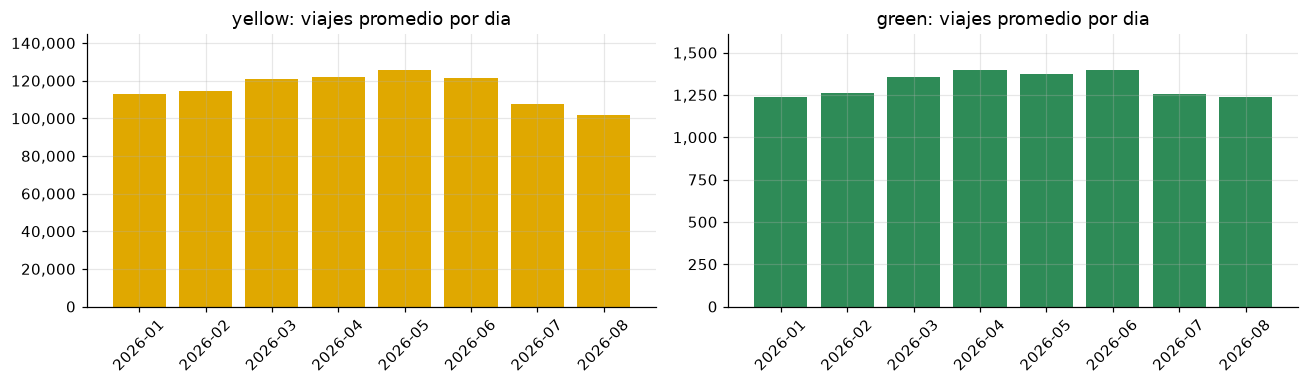

In [4]:
mensual = q('''
SELECT tipo,
       strftime(pickup, '%Y-%m')                              AS mes,
       count(*)                                              AS viajes,
       count(DISTINCT pickup::DATE)                          AS dias,
       round(count(*) / count(DISTINCT pickup::DATE))        AS viajes_por_dia
FROM viajes_limpios
GROUP BY tipo, mes
ORDER BY tipo DESC, mes
''')
tabla = mensual.pivot(index="mes", columns="tipo", values="viajes_por_dia")[["yellow", "green"]]
tabla["yellow vs enero (%)"] = 100 * (tabla["yellow"] / tabla["yellow"].iloc[0] - 1)
tabla["green vs enero (%)"] = 100 * (tabla["green"] / tabla["green"].iloc[0] - 1)
display(tabla)

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    eje.bar(tabla.index, tabla[tipo], color=COLORES[tipo])
    eje.set_title(f"{tipo}: viajes promedio por dia")
    eje.set_ylim(0, tabla[tipo].max() * 1.15)
    eje.tick_params(axis="x", rotation=45)
    eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
plt.tight_layout()
plt.show()

### P2 - Distribucion por hora del dia y dia de la semana

336 filas | 0.77 s


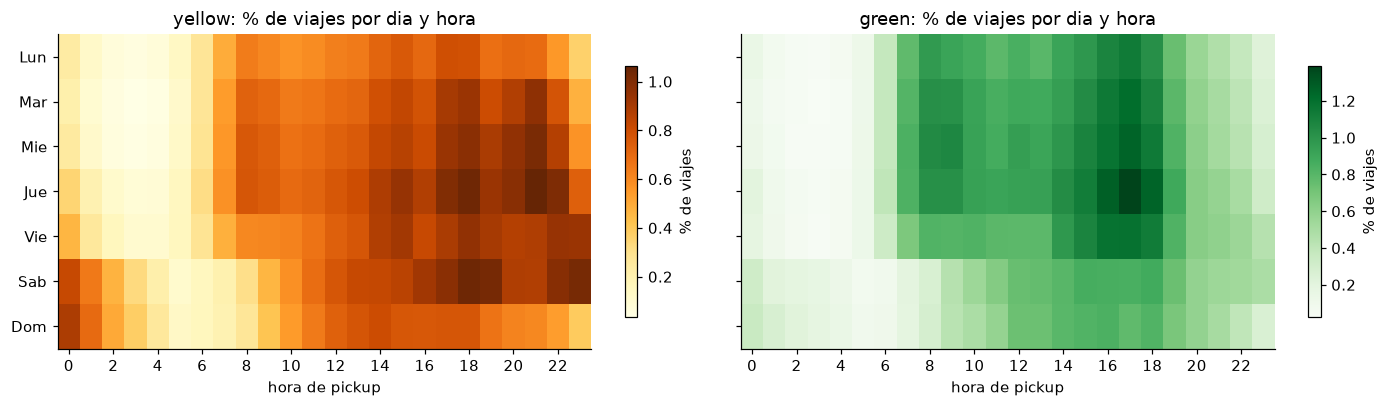

14 filas | 0.76 s


tipo,yellow,green
dia,,
Lun,"95,561.00","1,306.00"
Mar,"112,841.00","1,424.00"
Mie,"120,265.00","1,478.00"
Jue,"127,043.00","1,512.00"
Vie,"120,271.00","1,369.00"
Sab,"128,248.00","1,090.00"
Dom,"106,597.00","1,031.00"


In [5]:
hora_dia = q('''
SELECT tipo,
       isodow(pickup)                                                        AS dia,
       hour(pickup)                                                          AS hora,
       100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo)            AS pct_viajes
FROM viajes_limpios
GROUP BY tipo, dia, hora
''')

fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for eje, tipo, cmap in zip(ejes, ["yellow", "green"], ["YlOrBr", "Greens"]):
    m = hora_dia[hora_dia.tipo == tipo].pivot(index="dia", columns="hora", values="pct_viajes")
    im = eje.imshow(m.values, aspect="auto", cmap=cmap)
    eje.set_title(f"{tipo}: % de viajes por dia y hora")
    eje.set_yticks(range(7), DIAS)
    eje.set_xticks(range(0, 24, 2))
    eje.set_xlabel("hora de pickup")
    eje.grid(False)
    fig.colorbar(im, ax=eje, shrink=0.8, label="% de viajes")
plt.tight_layout()
plt.show()

por_dia = q('''
SELECT tipo, isodow(pickup) AS dia,
       round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_promedio_por_dia
FROM viajes_limpios
GROUP BY tipo, dia
ORDER BY tipo DESC, dia
''')
por_dia["dia"] = por_dia["dia"].map(lambda d: DIAS[d - 1])
display(por_dia.pivot(index="dia", columns="tipo", values="viajes_promedio_por_dia").loc[DIAS, ["yellow", "green"]])

### P3 - Dias con demanda anormal

10 filas | 0.47 s


,fecha,dia_semana,viajes,mediana_dia_semana,desviacion_pct
0,2026-02-23,Monday,22889,"101,781.00",-77.50
1,2026-01-25,Sunday,43538,"111,310.00",-60.90
2,2026-01-26,Monday,63256,"101,781.00",-37.90
3,2026-07-04,Saturday,81924,"130,757.00",-37.30
4,2026-07-03,Friday,83453,"125,949.00",-33.70
5,2026-07-05,Sunday,81619,"111,310.00",-26.70
6,2026-05-25,Monday,74974,"101,781.00",-26.30
7,2026-01-02,Friday,94172,"125,949.00",-25.20
8,2026-02-22,Sunday,83477,"111,310.00",-25.00
9,2026-08-21,Friday,95249,"125,949.00",-24.40


243 filas | 0.47 s


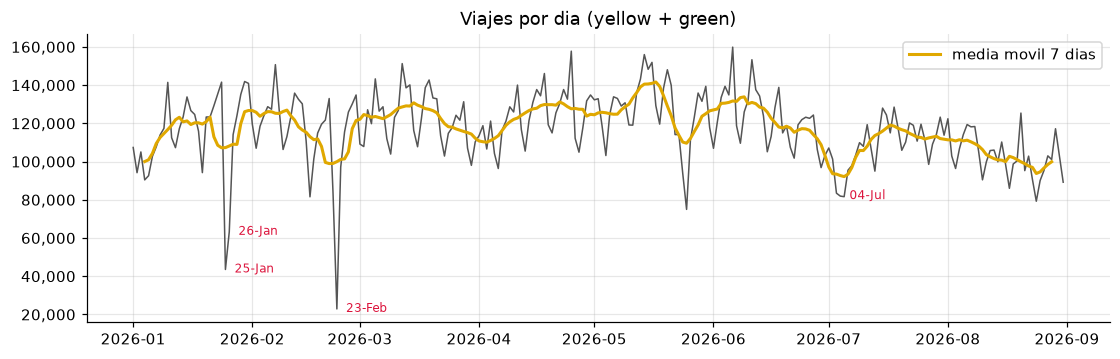

In [6]:
dias = q('''
WITH por_fecha AS (
    SELECT pickup::DATE AS fecha, count(*) AS viajes
    FROM viajes_limpios
    GROUP BY fecha
),
con_referencia AS (
    SELECT fecha, dayname(fecha) AS dia_semana, viajes,
           median(viajes) OVER (PARTITION BY isodow(fecha)) AS mediana_dia_semana
    FROM por_fecha
)
SELECT *, round(100.0 * (viajes / mediana_dia_semana - 1), 1) AS desviacion_pct
FROM con_referencia
ORDER BY abs(desviacion_pct) DESC
LIMIT 10
''')
display(dias)

serie = q("SELECT pickup::DATE AS fecha, count(*) AS viajes FROM viajes_limpios GROUP BY fecha ORDER BY fecha")
fig, eje = plt.subplots(figsize=(12, 3.4))
eje.plot(serie.fecha, serie.viajes, color="#555", lw=1)
eje.plot(serie.fecha, serie.viajes.rolling(7, center=True).mean(), color=COLORES["yellow"], lw=2, label="media movil 7 dias")
for _, fila in dias.head(4).iterrows():
    eje.annotate(fila.fecha.strftime("%d-%b"), (fila.fecha, fila.viajes), textcoords="offset points",
                 xytext=(6, -2), ha="left", fontsize=8, color="crimson")
eje.set_title("Viajes por dia (yellow + green)")
eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
eje.legend()
plt.show()

## B. Caracteristicas de los viajes

### P4 - El viaje tipico

In [7]:
tipico = q('''
SELECT tipo,
       count(*)                                                        AS viajes,
       round(median(trip_distance), 2)                                 AS distancia_mediana_mi,
       round(avg(trip_distance), 2)                                    AS distancia_media_mi,
       round(median(duracion_min), 1)                                  AS duracion_mediana_min,
       round(median(trip_distance / (duracion_min / 60)), 1)           AS velocidad_mediana_mph,
       round(avg(passenger_count) FILTER (passenger_count > 0), 2)     AS pasajeros_promedio,
       round(100.0 * count(*) FILTER (passenger_count = 1)
                   / count(passenger_count) FILTER (passenger_count > 0), 1) AS pct_un_pasajero
FROM viajes_limpios
GROUP BY tipo
ORDER BY viajes DESC
''')
tipico.set_index("tipo").T

2 filas | 2.42 s


tipo,yellow,green
viajes,"28,145,839.00","319,435.00"
distancia_mediana_mi,1.94,2.17
distancia_media_mi,3.53,3.38
duracion_mediana_min,14.20,13.40
velocidad_mediana_mph,9.30,10.00
pasajeros_promedio,1.25,1.32
pct_un_pasajero,82.60,84.20


### P5 - Velocidad a lo largo del dia (indicador de congestion)

48 filas | 0.87 s


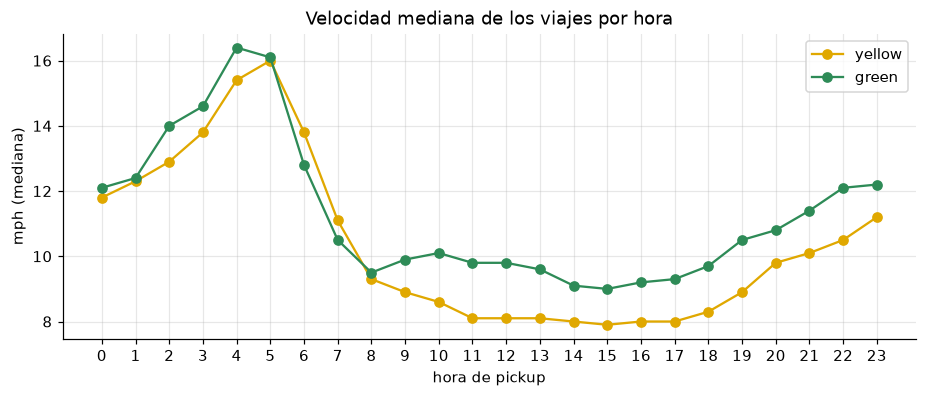

hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
tipo,,,,,,,,,,,,,,,,,,,,,,,,
green,12.10,12.40,14.00,14.60,16.40,16.10,12.80,10.50,9.50,9.90,10.10,9.80,9.80,9.60,9.10,9.00,9.20,9.30,9.70,10.50,10.80,11.40,12.10,12.20
yellow,11.80,12.30,12.90,13.80,15.40,16.00,13.80,11.10,9.30,8.90,8.60,8.10,8.10,8.10,8.00,7.90,8.00,8.00,8.30,8.90,9.80,10.10,10.50,11.20


In [8]:
velocidad = q('''
SELECT tipo, hour(pickup) AS hora,
       round(median(trip_distance / (duracion_min / 60)), 1) AS velocidad_mediana_mph,
       count(*)                                              AS viajes
FROM viajes_limpios
GROUP BY tipo, hora
ORDER BY tipo, hora
''')
fig, eje = plt.subplots(figsize=(10, 3.6))
for tipo in ["yellow", "green"]:
    d = velocidad[velocidad.tipo == tipo]
    eje.plot(d.hora, d.velocidad_mediana_mph, marker="o", color=COLORES[tipo], label=tipo)
eje.set_xticks(range(24))
eje.set_xlabel("hora de pickup")
eje.set_ylabel("mph (mediana)")
eje.set_title("Velocidad mediana de los viajes por hora")
eje.legend()
plt.show()
display(velocidad.pivot(index="hora", columns="tipo", values="velocidad_mediana_mph").T)

### P6 - Zonas de origen

In [9]:
borough = q('''
SELECT v.tipo, z.borough,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo), 2) AS pct_viajes
FROM viajes_limpios v
LEFT JOIN zonas z ON v.pu_zona = z.zona
GROUP BY v.tipo, z.borough
''')
display(borough.pivot(index="borough", columns="tipo", values="pct_viajes")[["yellow", "green"]]
        .fillna(0).sort_values("yellow", ascending=False))

top_zonas = q('''
SELECT v.tipo, z.borough, z.nombre_zona, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo), 2) AS pct_viajes
FROM viajes_limpios v
LEFT JOIN zonas z ON v.pu_zona = z.zona
GROUP BY v.tipo, z.borough, z.nombre_zona
QUALIFY row_number() OVER (PARTITION BY v.tipo ORDER BY count(*) DESC) <= 5
ORDER BY v.tipo DESC, viajes DESC
''')
top_zonas

15 filas | 0.77 s


tipo,yellow,green
borough,,
Manhattan,86.74,59.83
Queens,8.75,21.79
Brooklyn,3.60,15.75
Bronx,0.77,2.47
Unknown,0.10,0.09
N/A,0.02,0.05
Staten Island,0.01,0.02
EWR,0.00,0.00


10 filas | 0.82 s


,tipo,borough,nombre_zona,viajes,pct_viajes
0,yellow,Manhattan,Upper East Side South,1250841,4.44
1,yellow,Manhattan,Midtown Center,1169798,4.16
2,yellow,Queens,JFK Airport,1111499,3.95
3,yellow,Manhattan,Upper East Side North,1111127,3.95
4,yellow,Manhattan,Penn Station/Madison Sq West,867451,3.08
5,green,Manhattan,East Harlem North,86775,27.17
6,green,Manhattan,East Harlem South,41716,13.06
7,green,Queens,Forest Hills,15574,4.88
8,green,Manhattan,Central Park,12968,4.06
9,green,Manhattan,Morningside Heights,12431,3.89


## C. Diferencias entre taxis amarillos y verdes

### P7 - Comparacion de metricas por tipo

In [10]:
comparacion = q('''
SELECT tipo,
       count(*)                                                                    AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2)                          AS pct_del_total,
       round(median(trip_distance), 2)                                             AS distancia_mediana_mi,
       round(median(duracion_min), 1)                                              AS duracion_mediana_min,
       round(median(fare_amount), 2)                                               AS tarifa_mediana,
       round(median(total_amount), 2)                                              AS total_mediano,
       round(100.0 * avg((coalesce(ratecode_id, 0) IN (2, 3)
                         OR coalesce(airport_fee, 0) > 0
                         OR pu_zona IN (1, 132, 138) OR do_zona IN (1, 132, 138))::INT), 2) AS pct_aeropuerto,
       round(100.0 * avg((ratecode_id = 5)::INT) FILTER (ratecode_id IS NOT NULL), 2)       AS pct_tarifa_negociada,
       round(100.0 * avg((congestion_surcharge > 0)::INT) FILTER (congestion_surcharge IS NOT NULL), 1) AS pct_con_recargo_congestion,
       round(100.0 * avg((cbd_congestion_fee > 0)::INT), 1)                        AS pct_con_cargo_cbd
FROM viajes_limpios
GROUP BY tipo
ORDER BY viajes DESC
''')
display(comparacion.set_index("tipo").T)

tipo_viaje = q('''
SELECT CASE trip_type WHEN 1 THEN '1 - parada en la calle' WHEN 2 THEN '2 - despacho'
                      ELSE 'NULL (Flex Fare / sin dato)' END AS trip_type,
       count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct
FROM viajes_limpios
WHERE tipo = 'green'
GROUP BY ALL
ORDER BY viajes DESC
''')
tipo_viaje

2 filas | 3.31 s


tipo,yellow,green
viajes,"28,145,839.00","319,435.00"
pct_del_total,98.88,1.12
distancia_mediana_mi,1.94,2.17
duracion_mediana_min,14.20,13.40
tarifa_mediana,15.60,13.50
total_mediano,23.58,20.52
pct_aeropuerto,8.39,3.39
pct_tarifa_negociada,0.57,3.70
pct_con_recargo_congestion,90.40,33.60
pct_con_cargo_cbd,72.50,8.60


3 filas | 0.02 s


,trip_type,viajes,pct
0,1 - parada en la calle,263364,82.45
1,NULL (Flex Fare / sin dato),47593,14.90
2,2 - despacho,8478,2.65


## D. Variables relacionadas con el pago

### P8 - Formas de pago

11 filas | 2.17 s


,tipo,forma_pago,viajes,pct,distancia_mediana,total_mediano,propina_promedio
0,yellow,0 Flex Fare / sin dato,7038686,25.01,2.90,28.98,0.40
1,yellow,1 Tarjeta,18407933,65.40,1.71,22.35,4.24
2,yellow,2 Efectivo,2531891,9.00,1.60,18.55,0.00
3,yellow,3 Sin cargo,53877,0.19,1.33,16.85,0.00
4,yellow,4 Disputa,113451,0.40,1.61,18.65,0.00
5,yellow,5-6 Otro,1,0.00,3.20,0.00,0.00
6,green,0 Flex Fare / sin dato,47593,14.90,5.01,26.48,0.76
7,green,1 Tarjeta,209543,65.60,2.00,20.94,3.79
8,green,2 Efectivo,61572,19.28,1.82,16.10,0.00
9,green,3 Sin cargo,499,0.16,0.90,11.90,0.01


16 filas | 0.86 s


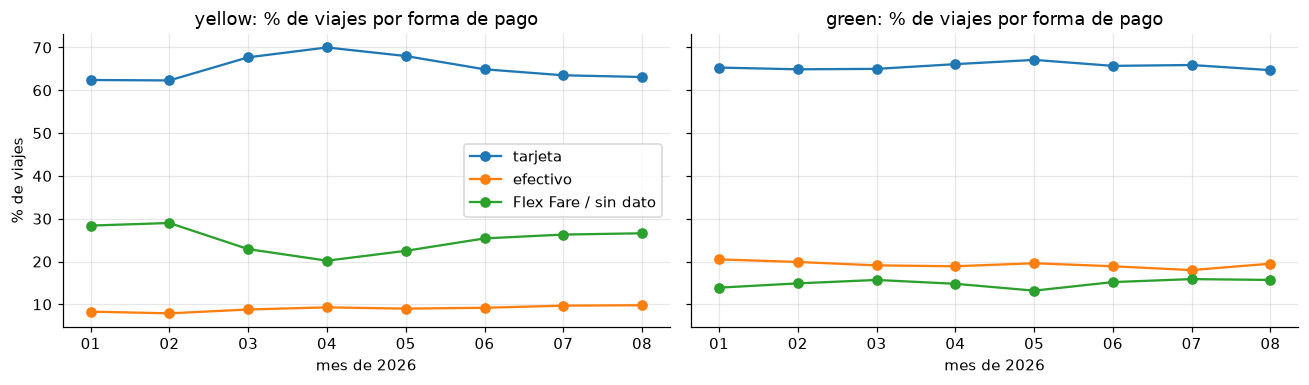

In [11]:
pagos = q('''
SELECT tipo,
       CASE coalesce(payment_type, 0)
            WHEN 0 THEN '0 Flex Fare / sin dato' WHEN 1 THEN '1 Tarjeta' WHEN 2 THEN '2 Efectivo'
            WHEN 3 THEN '3 Sin cargo' WHEN 4 THEN '4 Disputa' ELSE '5-6 Otro' END AS forma_pago,
       count(*)                                                       AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS pct,
       round(median(trip_distance), 2)                                AS distancia_mediana,
       round(median(total_amount), 2)                                 AS total_mediano,
       round(avg(tip_amount), 2)                                      AS propina_promedio
FROM viajes_limpios
GROUP BY tipo, forma_pago
ORDER BY tipo DESC, forma_pago
''')
display(pagos)

pagos_mes = q('''
SELECT tipo, strftime(pickup, '%m') AS mes,
       round(100.0 * avg((coalesce(payment_type, 0) = 1)::INT), 1)   AS pct_tarjeta,
       round(100.0 * avg((coalesce(payment_type, 0) = 2)::INT), 1)   AS pct_efectivo,
       round(100.0 * avg((coalesce(payment_type, 0) = 0)::INT), 1)   AS pct_flex_fare
FROM viajes_limpios
GROUP BY tipo, mes
ORDER BY tipo DESC, mes
''')

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for eje, tipo in zip(ejes, ["yellow", "green"]):
    d = pagos_mes[pagos_mes.tipo == tipo]
    eje.plot(d.mes, d.pct_tarjeta, marker="o", label="tarjeta")
    eje.plot(d.mes, d.pct_efectivo, marker="o", label="efectivo")
    eje.plot(d.mes, d.pct_flex_fare, marker="o", label="Flex Fare / sin dato")
    eje.set_title(f"{tipo}: % de viajes por forma de pago")
    eje.set_xlabel("mes de 2026")
ejes[0].set_ylabel("% de viajes")
ejes[0].legend()
plt.tight_layout()
plt.show()

### P9 - Propinas

2 filas | 1.07 s


,tipo,viajes_con_tarjeta,propina_mediana_pct,pct_sin_propina,pct_propina_30_o_mas
0,yellow,18407854,26.40,8.80,32.10
1,green,209542,23.60,8.30,17.80


48 filas | 0.62 s


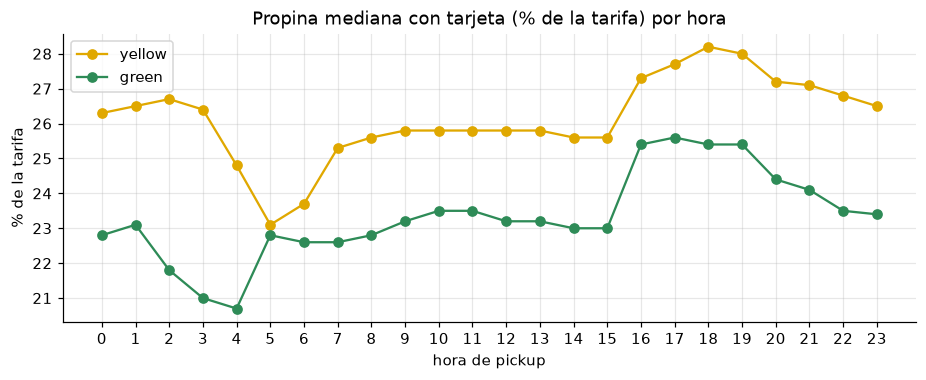

In [12]:
propinas = q('''
SELECT tipo,
       count(*)                                                        AS viajes_con_tarjeta,
       round(100 * median(tip_amount / fare_amount), 1)                AS propina_mediana_pct,
       round(100.0 * avg((tip_amount = 0)::INT), 1)                    AS pct_sin_propina,
       round(100.0 * avg((tip_amount / fare_amount >= 0.30)::INT), 1)  AS pct_propina_30_o_mas
FROM viajes_limpios
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY tipo
ORDER BY viajes_con_tarjeta DESC
''')
display(propinas)

propina_hora = q('''
SELECT tipo, hour(pickup) AS hora,
       round(100 * median(tip_amount / fare_amount), 1) AS propina_mediana_pct
FROM viajes_limpios
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY tipo, hora
ORDER BY tipo, hora
''')
fig, eje = plt.subplots(figsize=(10, 3.4))
for tipo in ["yellow", "green"]:
    d = propina_hora[propina_hora.tipo == tipo]
    eje.plot(d.hora, d.propina_mediana_pct, marker="o", color=COLORES[tipo], label=tipo)
eje.set_xticks(range(24))
eje.set_xlabel("hora de pickup")
eje.set_ylabel("% de la tarifa")
eje.set_title("Propina mediana con tarjeta (% de la tarifa) por hora")
eje.legend()
plt.show()

### P10 - Costo por milla y peso de los recargos

In [13]:
costos = q('''
SELECT tipo,
       round(median(fare_amount / trip_distance), 2)                           AS tarifa_por_milla_mediana,
       round(median(fare_amount) FILTER (trip_distance BETWEEN 1 AND 2), 2)    AS tarifa_mediana_1_a_2_mi,
       round(median(fare_amount) FILTER (trip_distance BETWEEN 5 AND 6), 2)    AS tarifa_mediana_5_a_6_mi,
       round(avg(total_amount - fare_amount - tip_amount - tolls_amount), 2)   AS recargos_promedio,
       round(100 * sum(total_amount - fare_amount - tip_amount - tolls_amount)
                 / sum(total_amount), 1)                                       AS pct_del_total_en_recargos,
       round(avg(coalesce(cbd_congestion_fee, 0)), 2)                          AS cargo_cbd_promedio
FROM viajes_limpios
WHERE ratecode_id = 1 AND total_amount > 0
GROUP BY tipo
ORDER BY tipo DESC
''')
costos.set_index("tipo").T

2 filas | 1.20 s


tipo,yellow,green
tarifa_por_milla_mediana,7.75,6.90
tarifa_mediana_1_a_2_mi,11.40,10.70
tarifa_mediana_5_a_6_mi,28.20,28.20
recargos_promedio,5.57,3.40
pct_del_total_en_recargos,21.50,15.00
cargo_cbd_promedio,0.57,0.06


## E. Distribucion de los valores relevantes

### P11 - Percentiles y forma de las distribuciones

In [14]:
variables = ["trip_distance", "duracion_min", "fare_amount", "tip_amount", "total_amount"]
partes = []
for var in variables:
    partes.append(f'''
    SELECT tipo, '{var}' AS variable,
           min({var}) AS minimo,
           quantile_cont({var}, 0.01) AS p01, quantile_cont({var}, 0.25) AS p25,
           quantile_cont({var}, 0.50) AS mediana, quantile_cont({var}, 0.75) AS p75,
           quantile_cont({var}, 0.99) AS p99, max({var}) AS maximo,
           avg({var}) AS media, skewness({var}) AS asimetria
    FROM viajes GROUP BY tipo''')
percentiles = q(" UNION ALL ".join(partes) + " ORDER BY variable, tipo DESC")
percentiles.round(2)

10 filas | 13.73 s


,tipo,variable,minimo,p01,p25,mediana,p75,p99,maximo,media,asimetria
0,yellow,duracion_min,"-300,517.52",0.00,8.33,13.93,22.12,71.17,"17,165.42",17.64,"-3,273.23"
1,green,duracion_min,-687.00,0.07,8.30,13.07,20.43,82.23,"2,456.37",20.80,17.44
2,yellow,fare_amount,"-2,555.20",3.00,10.00,15.60,26.32,82.10,"7,045.00",21.26,12.09
3,green,fare_amount,-500.00,0.00,8.60,13.50,19.80,80.00,"1,676.70",17.01,9.70
4,yellow,tip_amount,-222.00,0.00,0.00,2.00,3.99,17.44,766.00,2.83,5.11
5,green,tip_amount,-14.00,0.00,0.00,2.00,3.84,15.39,495.00,2.62,40.66
6,yellow,total_amount,"-2,560.20",8.00,17.35,23.58,34.56,105.75,"7,053.50",30.07,8.10
7,green,total_amount,-501.50,5.00,15.00,20.46,29.70,97.20,"1,678.20",25.49,7.89
8,yellow,trip_distance,0.00,0.00,1.02,1.86,3.80,19.50,"328,522.20",5.55,305.36
9,green,trip_distance,0.00,0.00,1.25,2.07,3.69,17.76,"179,830.92",13.35,109.13


100 filas | 0.69 s


90 filas | 0.71 s


120 filas | 0.75 s


48 filas | 0.63 s


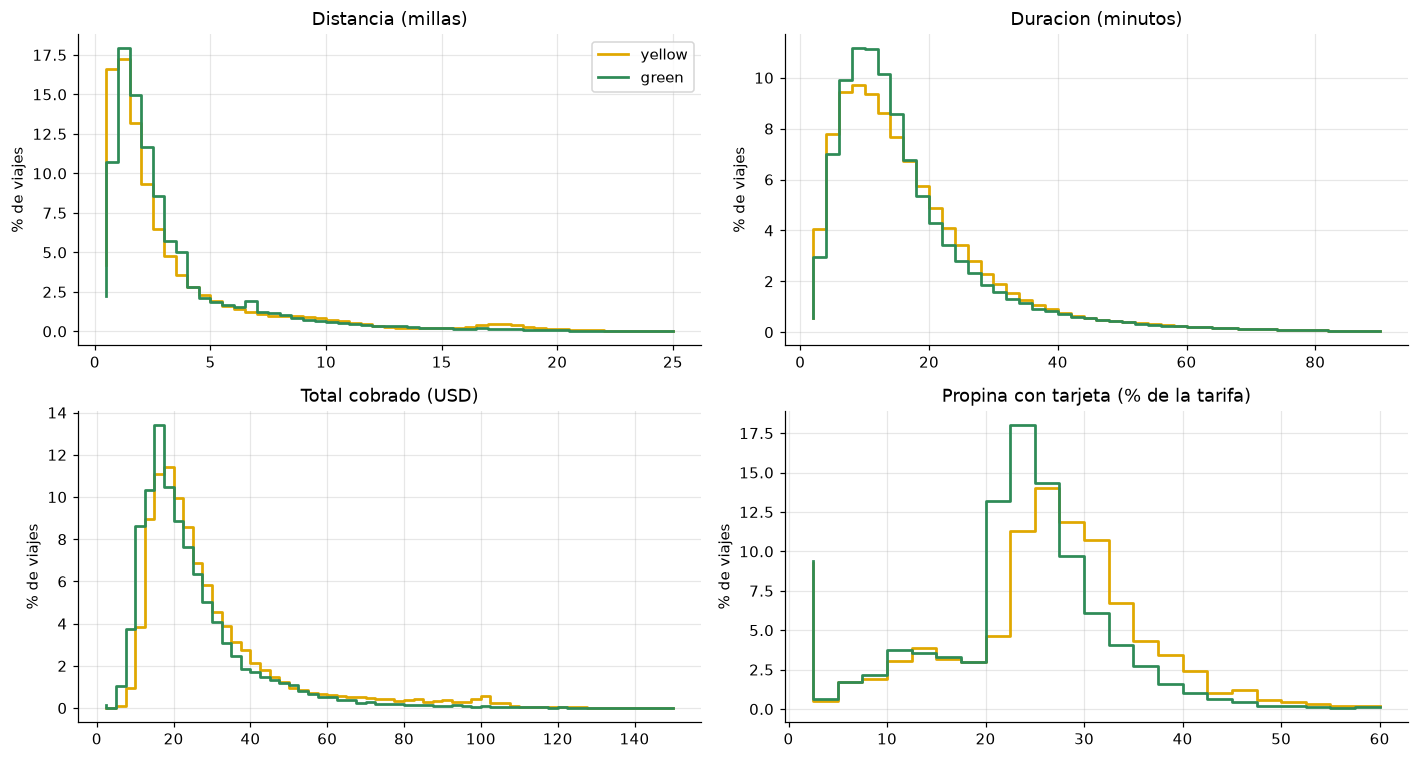

In [15]:
def histograma(expr, ancho, maximo, filtro="TRUE"):
    return q(f'''
    SELECT tipo, floor(({expr}) / {ancho}) * {ancho} AS desde,
           100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo) AS pct
    FROM viajes_limpios
    WHERE {filtro} AND ({expr}) < {maximo}
    GROUP BY tipo, desde
    ORDER BY desde
    ''')

graficos = [
    ("Distancia (millas)", histograma("trip_distance", 0.5, 25), 0.5),
    ("Duracion (minutos)", histograma("duracion_min", 2, 90), 2),
    ("Total cobrado (USD)", histograma("total_amount", 2.5, 150), 2.5),
    ("Propina con tarjeta (% de la tarifa)",
     histograma("100 * tip_amount / fare_amount", 2.5, 60, "payment_type = 1 AND fare_amount > 0"), 2.5),
]
fig, ejes = plt.subplots(2, 2, figsize=(13, 7))
for eje, (titulo, df, ancho) in zip(ejes.flat, graficos):
    for tipo in ["yellow", "green"]:
        d = df[df.tipo == tipo]
        eje.step(d.desde + ancho, d.pct, where="pre", color=COLORES[tipo], label=tipo, lw=1.8)
    eje.set_title(titulo)
    eje.set_ylabel("% de viajes")
ejes[0, 0].legend()
plt.tight_layout()
plt.show()

## F. Valores atipicos e inconsistencias

### P12 - Registros que violan reglas fisicas o logicas

In [16]:
reglas = q('''
SELECT tipo, vendor_id,
       count(*)                                                                    AS registros,
       count(*) FILTER (duracion_min > 0 AND trip_distance / (duracion_min / 60) > 80) AS velocidad_mayor_80mph,
       count(*) FILTER (trip_distance = 0 AND fare_amount > 20)                    AS distancia_0_tarifa_alta,
       count(*) FILTER (duracion_min > 180)                                        AS mas_de_3_horas,
       count(*) FILTER (fare_amount < 0)                                           AS tarifa_negativa,
       count(*) FILTER (payment_type = 1 AND fare_amount > 0 AND tip_amount > fare_amount) AS propina_mayor_tarifa,
       count(*) FILTER (passenger_count = 0)                                       AS pasajeros_cero
FROM viajes
GROUP BY ALL
ORDER BY tipo DESC, vendor_id
''')
display(reglas)

tasas = reglas.groupby("tipo").sum(numeric_only=True).drop(columns="vendor_id")
display((100 * tasas.div(tasas["registros"], axis=0)).drop(columns="registros")
        .rename(columns=lambda c: c + " (%)").round(3))

7 filas | 0.65 s


,tipo,vendor_id,registros,velocidad_mayor_80mph,distancia_0_tarifa_alta,mas_de_3_horas,tarifa_negativa,propina_mayor_tarifa,pasajeros_cero
0,yellow,1,5467071,6213,28176,2908,0,6963,81915
1,yellow,2,23809774,1659,522501,7183,157364,26870,9444
2,yellow,6,59390,115,0,36,0,0,0
3,yellow,7,367120,0,2101,0,0,600,0
4,green,1,28696,335,251,0,0,83,4166
5,green,2,273571,769,3404,1270,999,897,361
6,green,6,34847,54,0,17,0,0,0


,velocidad_mayor_80mph (%),distancia_0_tarifa_alta (%),mas_de_3_horas (%),tarifa_negativa (%),propina_mayor_tarifa (%),pasajeros_cero (%)
tipo,,,,,,
green,0.34,1.08,0.38,0.30,0.29,1.34
yellow,0.03,1.86,0.03,0.53,0.12,0.31


In [17]:
q('''
SELECT tipo,
       CASE coalesce(payment_type, 0)
            WHEN 0 THEN '0 Flex Fare / sin dato' WHEN 1 THEN '1 Tarjeta' WHEN 2 THEN '2 Efectivo'
            WHEN 3 THEN '3 Sin cargo' WHEN 4 THEN '4 Disputa' ELSE '5-6 Otro' END AS forma_pago,
       count(*)                                                          AS registros,
       count(*) FILTER (total_amount < 0)                                AS total_negativo,
       round(100.0 * count(*) FILTER (total_amount < 0) / count(*), 2)   AS pct_negativo
FROM viajes
GROUP BY ALL
ORDER BY tipo DESC, forma_pago
''')

11 filas | 0.36 s


,tipo,forma_pago,registros,total_negativo,pct_negativo
0,yellow,0 Flex Fare / sin dato,7716688,94,0.00
1,yellow,1 Tarjeta,18941008,3511,0.02
2,yellow,2 Efectivo,2708031,39646,1.46
3,yellow,3 Sin cargo,98138,17730,18.07
4,yellow,4 Disputa,239488,100854,42.11
5,yellow,5-6 Otro,2,0,0.00
6,green,0 Flex Fare / sin dato,48775,0,0.00
7,green,1 Tarjeta,219980,137,0.06
8,green,2 Efectivo,65921,43,0.07
9,green,3 Sin cargo,1688,564,33.41


### P13 - ¿Los montos atipicamente altos son errores?

In [18]:
q('''
WITH limites AS (
    SELECT tipo,
           quantile_cont(total_amount, 0.25) AS q1,
           quantile_cont(total_amount, 0.75) AS q3,
           q3 + 1.5 * (q3 - q1)              AS limite_superior
    FROM viajes_limpios
    GROUP BY tipo
),
marcados AS (
    SELECT v.*, l.limite_superior,
           v.total_amount > l.limite_superior AS atipico,
           (coalesce(v.ratecode_id, 0) IN (2, 3) OR coalesce(v.airport_fee, 0) > 0
            OR v.pu_zona IN (1, 132, 138) OR v.do_zona IN (1, 132, 138)) AS aeropuerto
    FROM viajes_limpios v JOIN limites l USING (tipo)
)
SELECT tipo,
       round(any_value(limite_superior), 2)                                  AS limite_superior_usd,
       count(*) FILTER (atipico)                                             AS atipicos,
       round(100.0 * count(*) FILTER (atipico) / count(*), 2)                AS pct_atipicos,
       round(100.0 * avg(aeropuerto::INT), 1)                                AS pct_aeropuerto_en_todos,
       round(100.0 * avg(aeropuerto::INT) FILTER (atipico), 1)               AS pct_aeropuerto_en_atipicos,
       round(median(trip_distance) FILTER (atipico), 1)                      AS distancia_mediana_atipicos,
       round(median(trip_distance) FILTER (NOT atipico), 1)                  AS distancia_mediana_resto
FROM marcados
GROUP BY tipo
ORDER BY atipicos DESC
''')

2 filas | 3.60 s


,tipo,limite_superior_usd,atipicos,pct_atipicos,pct_aeropuerto_en_todos,pct_aeropuerto_en_atipicos,distancia_mediana_atipicos,distancia_mediana_resto
0,yellow,59.85,2382723,8.47,8.40,75.20,13.00,1.80
1,green,51.57,20636,6.46,3.40,16.70,10.60,2.00


### P14 - Distancia 0 con tarifa alta

In [19]:
q('''
SELECT tipo,
       CASE coalesce(payment_type, 0) WHEN 0 THEN '0 Flex Fare / sin dato' WHEN 1 THEN '1 Tarjeta'
            WHEN 2 THEN '2 Efectivo' ELSE '3+ Otro' END                AS forma_pago,
       coalesce(ratecode_id::VARCHAR, 'NULL')                           AS ratecode_id,
       count(*)                                                         AS registros,
       round(100.0 * count(*) / sum(count(*)) OVER (), 1)               AS pct_del_total,
       round(median(fare_amount), 2)                                    AS tarifa_mediana
FROM viajes
WHERE trip_distance = 0 AND fare_amount > 20
GROUP BY tipo, forma_pago, ratecode_id
ORDER BY registros DESC
LIMIT 8
''')

8 filas | 0.10 s


,tipo,forma_pago,ratecode_id,registros,pct_del_total,tarifa_mediana
0,yellow,0 Flex Fare / sin dato,NULL,444234,79.80,31.10
1,yellow,1 Tarjeta,5,70882,12.70,74.70
2,yellow,2 Efectivo,2,8180,1.50,70.00
3,yellow,1 Tarjeta,1,5724,1.00,24.70
4,yellow,1 Tarjeta,2,5465,1.00,70.00
5,yellow,2 Efectivo,5,4503,0.80,81.00
6,yellow,1 Tarjeta,99,2778,0.50,30.50
7,yellow,1 Tarjeta,3,2343,0.40,23.00


In [20]:
q('''
SELECT tipo,
       count(*) FILTER (coalesce(payment_type, 0) = 0)                               AS viajes_flex_fare,
       round(100.0 * avg((trip_distance = 0)::INT) FILTER (coalesce(payment_type, 0) = 0), 1) AS pct_flex_con_distancia_0,
       round(100.0 * avg((trip_distance = 0)::INT) FILTER (coalesce(payment_type, 0) <> 0), 1) AS pct_resto_con_distancia_0
FROM viajes
GROUP BY tipo
ORDER BY tipo DESC
''')

2 filas | 0.32 s


,tipo,viajes_flex_fare,pct_flex_con_distancia_0,pct_resto_con_distancia_0
0,yellow,7716688,8.70,1.30
1,green,48775,2.10,3.90


## Respuestas a las preguntas

P1. ¿Como cambia la cantidad de viajes de un mes a otro y es igual para amarillos y verdes?

Los dos tipos de taxi suben y bajan en los mismos meses. Los viajes aumentan de enero a abril y mayo, y bajan en julio y agosto. En los amarillos, un dia normal de mayo tuvo cerca de 125 mil viajes y uno de agosto cerca de 102 mil, casi 20 % menos, probablemente porque mucha gente sale de la ciudad en verano. Febrero parece un mes bajo si se ve el total, pero es porque tiene menos dias. Por dia tuvo mas viajes que enero. Los verdes cambian menos, entre unos 1,235 y 1,400 viajes por dia.

P2. ¿A que horas y que dias se hacen mas viajes?

Los amarillos tienen mas viajes entre las 5 y las 7 de la noche, pero tambien se usan mucho de noche, sobre todo viernes y sabado. Su mejor dia es el sabado y el peor es el lunes. Los verdes se usan sobre todo de lunes a viernes entre las 2 y las 6 de la tarde, casi no tienen viajes de noche y los fines de semana tienen cerca de 30 % menos viajes que un jueves.

P3. ¿Hubo dias con muchos mas o muchos menos viajes de lo normal?

Si, y todos fueron dias con muchos menos viajes. El 23 de febrero hubo cerca de 77 % menos viajes que un lunes normal, y el 25 de enero 61 % menos. Al ser dias de invierno, podrian ser tormentas de nieve, aunque los datos no traen el clima para confirmarlo. Otras bajas coinciden con feriados como el 4 de julio y el Memorial Day.

P4. ¿Como es un viaje normal?

Es corto y de una sola persona. La mitad de los viajes recorre menos de 2 millas y dura menos de 14 minutos. En mas del 80 % de los viajes iba un solo pasajero. El promedio de distancia sale casi al doble de la mediana porque unos pocos viajes largos, como los de aeropuerto, lo suben.

P5. ¿Cambia la velocidad de los taxis durante el dia?

Si, bastante. A las 5 de la manana los amarillos van a unas 16 millas por hora y entre las 10 de la manana y las 5 de la tarde bajan a unas 8, por el trafico. Los verdes van un poco mas rapido de dia porque no pasan por el centro de Manhattan.

P6. ¿De donde salen los viajes?

Casi 9 de cada 10 viajes amarillos salen de Manhattan y luego de los aeropuertos JFK y LaGuardia. Los verdes dependen de pocas zonas. Solo East Harlem Norte y Sur juntan cerca del 40 % de sus viajes, y el resto sale del norte de Manhattan, Queens y Brooklyn. Esto pasa porque los verdes no pueden recoger pasajeros en el sur de Manhattan ni en los aeropuertos.

P7. ¿En que se diferencian los viajes amarillos y verdes?

Los verdes son apenas el 1.1 % de todos los viajes. Sus viajes son un poco mas largos pero mas baratos, porque pagan menos recargos. Cerca del 90 % de los amarillos paga recargo por congestion y el 72 % el cargo por entrar al sur de Manhattan, mientras que en los verdes es cerca de un tercio y menos del 10 %. Los amarillos tienen mas del doble de viajes de aeropuerto (8.4 % contra 3.4 %) y los verdes usan mas la tarifa negociada (3.7 % contra 0.6 %).

P8. ¿Como paga la gente?

La tarjeta es la forma mas comun, con cerca del 65 % de los viajes en ambos tipos. En los amarillos, una cuarta parte son viajes Flex Fare, con precio acordado antes de salir, que suelen ser mas largos y caros. El efectivo se usa el doble en los verdes (19 %) que en los amarillos (9 %). Las propinas en efectivo siempre aparecen en cero porque no se registran.

P9. ¿Cuanta propina se deja y depende de la hora?

Con tarjeta, la propina tipica es cerca del 26 % de la tarifa en los amarillos y 24 % en los verdes. Menos del 10 % no deja propina. Se deja un poco mas en la tarde y noche y un poco menos muy temprano. Casi nadie deja entre 17 % y 20 %, y de golpe muchos dejan 20 % o mas, porque la pantalla del taxi sugiere opciones desde 20 %.

P10. ¿Cuanto cuesta la milla y cuanto pesan los recargos?

Para la misma distancia la tarifa es casi igual en los dos tipos. Lo que encarece a los amarillos son los recargos, unos 5.60 dolares por viaje, que son el 21.5 % del total, contra unos 3.40 dolares y 15 % en los verdes. La milla tambien sale mas cara en los amarillos porque avanzan mas lento y el taximetro cobra el tiempo detenido.

P11. ¿Como se reparten la distancia, la duracion, el total y la propina?

En todas, la mayoria de viajes tiene valores bajos y unos pocos tienen valores enormes o imposibles, como distancias de miles de millas o duraciones negativas. Por eso conviene usar la mediana y no el promedio. Con los datos limpios, la mayoria de viajes mide entre media milla y 3 millas y dura entre 5 y 20 minutos. En los amarillos se nota un pequeno grupo de viajes largos y caros que son los del aeropuerto JFK.

P12. ¿Cuantos registros tienen datos imposibles o raros?

Cada problema afecta a menos del 2 % de los registros, pero eso son cientos de miles de viajes. El mas comun es distancia cero con tarifa alta. Las tarifas negativas aparecen casi siempre en pagos en disputa o sin cargo, o sea que son devoluciones. Los errores dependen de la empresa del taximetro. La empresa 1 tiene el 18 % de los viajes amarillos pero cerca del 78 % de las velocidades imposibles, y la empresa 2 tiene todas las tarifas negativas.

P13. ¿Los cobros muy altos son errores?

No en su mayoria. Con la regla del rango intercuartil, los viajes amarillos de mas de unos 60 dolares salen como atipicos, pero tres de cada cuatro son viajes de aeropuerto de unas 13 millas. Son viajes reales, asi que no se deben borrar solo por costar mucho.

P14. ¿Por que hay viajes con distancia cero y tarifa alta?

Cerca del 80 % son viajes Flex Fare, donde el precio se acuerda antes y muchas veces no se anota la distancia. El resto son sobre todo tarifas negociadas o la tarifa fija a JFK. El cobro esta bien, lo que falta es la distancia. Por eso se dejan fuera al estudiar distancia o velocidad, pero sirven para estudiar ingresos.

### Hallazgos principales

1. Los taxis amarillos y verdes son dos servicios distintos. Los verdes atienden pocas zonas fuera del centro, sobre todo de dia y entre semana, mientras los amarillos trabajan en Manhattan, de dia y de noche, y su mejor dia es el sabado.

2. El trafico hace que los viajes tarden el doble durante el dia, y eso tambien los hace mas caros, porque el taximetro cobra el tiempo detenido.

3. Una cuarta parte de los viajes amarillos son Flex Fare y explican la mayoria de los viajes con distancia cero. No son errores de cobro sino datos que faltan, y no conviene borrarlos.

4. Los cobros que parecen exagerados son casi siempre viajes al aeropuerto, y los cobros negativos son devoluciones. Para limpiar los datos hay que usar reglas con sentido y no solo reglas estadisticas.

5. Hay mas viajes en primavera que en verano, y algunos dias de invierno perdieron mas de la mitad de los viajes.